# Линейная регрессия

В прошлом ноутбуке мы научились исследовать связи между переменными. Теперь попробуем ответить на следующий вопрос: можно ли описать эту связь математическим уравнением?

Для этого используется **линейная регрессия**.

В этом ноутбуке мы:

- построим линейную регрессию
- разберём смысл коэффициентов модели
- научимся интерпретировать результаты
- познакомимся с основными метриками качества
- проверим предпосылки модели

## Импорт библиотек

In [1]:
# %pip install seaborn

In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import statsmodels.api as sm

from scipy import stats

## Что такое линейная регрессия?

Линейная регрессия описывает зависимость между переменными при помощи прямой линии. Модель пытается подобрать такую прямую, которая лучше всего проходит через облако наблюдений.

## Уравнение линейной регрессии

Линейная регрессия задаётся уравнением:

$$
y = b_0 + b_1x
$$

где:

- $y$ — зависимая переменная
- $x$ — независимая переменная
- $b_0$ — свободный член
- $b_1$ — коэффициент наклона.

**Интерпретация коэффициентов**

Коэффициент $b_1$ показывает, насколько в среднем изменяется зависимая переменная при увеличении $x$ на одну единицу.

**Пример данных**

In [3]:
experience = np.array(
    [1,2,3,4,5,6,7,8,9,10]
)

salary = np.array(
    [40,42,48,50,55,58,63,67,71,75]
)

**Визуализация**

Перед тем, как начинать построение модели, важно посмотреть на данные наглядно. В нашем случае мы видим,что точки почти полностью ложатся на воображаемую восходящую прямую: большему опыту соответствует большая зарплата.

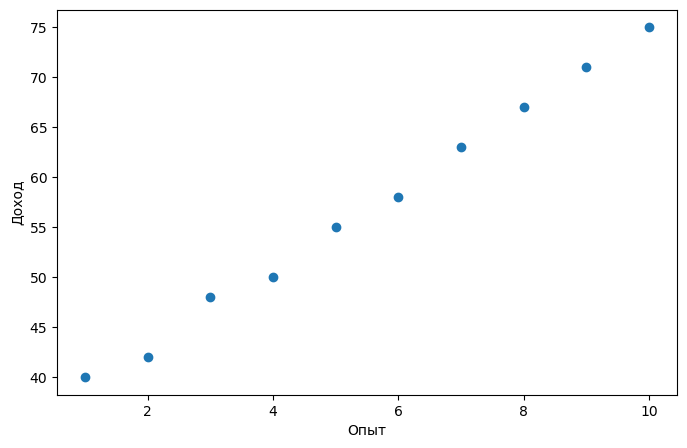

In [4]:
plt.figure(figsize=(8,5))

plt.scatter(
    experience,
    salary
)

plt.xlabel("Опыт")
plt.ylabel("Доход")

plt.show()

Попробуем описать эту зависимость прямой линией.

## Подготовка данных

In [5]:
df = pd.DataFrame({
    "experience": experience,
    "salary": salary
})

In [6]:
df

,experience,salary
0,1,40
1,2,42
2,3,48
3,4,50
4,5,55
5,6,58
6,7,63
7,8,67
8,9,71
9,10,75


Задаём X и y модели

In [7]:
X = sm.add_constant(
    df["experience"]
)

y = df["salary"]

**Обучение модели**

In [8]:
model = sm.OLS(
    y,
    X
).fit()

### Как читать сводку по модели?

Ниже мы видим сводку (summary) по построенной модели.

Таблица разделена на 3 части:

- Верхняя даёт обзор модели целиком. Нас будет интересовать $R^2$, а при сравнении нескольких моделей можно смотреть на AIC, BIC, F-statistic
- Средняя описывает предикторы (объясняющие переменные): значение коэффициента, его стат. значимость, доверительные интервалы
- Нижняя даёт диагностические показатели

In [9]:
model.summary()

/lib/python3.13/site-packages/scipy/stats/_axis_nan_policy.py:418: UserWarning: `kurtosistest` p-value may be inaccurate with fewer than 20 observations; only n=10 observations were given.
  return hypotest_fun_in(*args, **kwds)


<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                 salary   R-squared:                       0.996
Model:                            OLS   Adj. R-squared:                  0.996
Method:                 Least Squares   F-statistic:                     2156.
Date:                Wed, 17 Jun 2026   Prob (F-statistic):           5.12e-11
Time:                        01:10:01   Log-Likelihood:                -10.545
No. Observations:                  10   AIC:                             25.09
Df Residuals:                       8   BIC:                             25.69
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         35.0667      0.530     66.103      0.000      33.843      36.290
experience     3.9697      0.085     46.432      0.000       3.773       4.167
==============================================================================
Omnibus:                        0.640   Durbin-Watson:                   3.098
Prob(Omnibus):                  0.726   Jarque-Bera (JB):                0.556
Skew:                          -0.166   Prob(JB):                        0.757
Kurtosis:                       1.893   Cond. No.                         13.7
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

**Из основного:**

- $R^2$ составил 0.996 или 99,6% вариации зависимой переменной объясняют включенные в модель предикторы
- Коэффициенты (и константа, и коэффициент при опыте работы) значимы , доверительные интервалы не пересекают ноль.
- Константа составила 35.0667, то есть при отсутствии опыта работы зарплата составит 35
- Коэффицент для опыта работы составил 3.9697, то есть с ростом опыта работы на 1 единицу (допустим, лет) при прочих равных зарплата вырастет почти на 4 единицы (допустим, тыс. руб)


**Коэффициенты модели**

На начальных этапах может быть интересно собирать полученные результаты в уравнение, подставляя значения в которое можно получить предсказанные значения.

Так мы можем вывести коэффициенты модели

In [10]:
model.params

const         35.066667
experience     3.969697
dtype: float64

Тогда уравнение модели (с небольшими округлениями) выглядит так:

$$
\hat{y} = 35.07 + 3.97x
$$

**Интерпретация**

каждый дополнительный год опыта связан с увеличением дохода примерно на 3.97 единиц.

### Визуализация линии регрессии

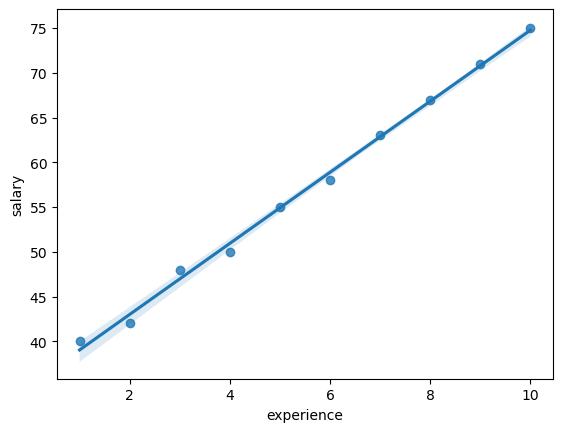

In [11]:
sns.regplot(
    data=df,
    x="experience",
    y="salary"
)

plt.show()

### Качество модели

После построения модели нужно понять, насколько хорошо она описывает данные.

Коэффициент детерминации

$$
R^2 = 1 - \frac{RSS}{TSS}
$$

R² показывает, какую долю вариации зависимой переменной объясняет модель.

In [13]:
model.rsquared

np.float64(0.996302979213547)

**Интерпретация**

$R^2 = 0.996$

Модель объясняет примерно 99% вариации дохода.

### Статистическая значимость коэффициентов

Для каждого коэффициента проверяется гипотеза:

$$
H_0: \beta_1 = 0
$$

$$
H_1: \beta_1 \ne 0
$$

Если p-value меньше уровня значимости, коэффициент считается статистически значимым.

In [14]:
model.pvalues

const         3.052010e-12
experience    5.115745e-11
dtype: float64

### Доверительные интервалы

Доверительный интервал показывает диапазон правдоподобных значений коэффициента.

In [15]:
model.conf_int()

,0,1
const,33.843366,36.289967
experience,3.772544,4.166850


### Остатки

Остаток — это разница между фактическим и предсказанным значением.

$$
e_i = y_i - \hat{y}_i
$$

In [16]:
residuals = model.resid

Можно посмотреть визуально

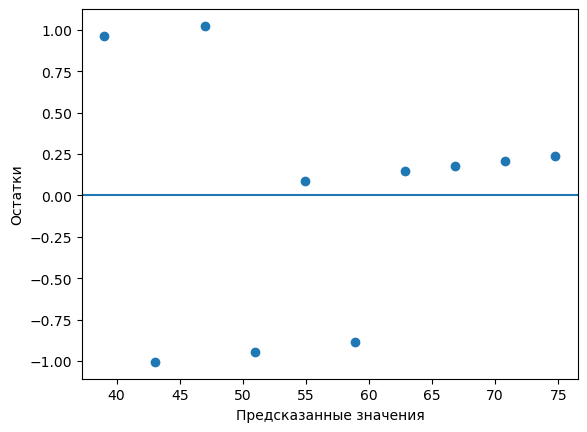

In [17]:
plt.scatter(
    model.fittedvalues,
    residuals
)

plt.axhline(0)

plt.xlabel("Предсказанные значения")
plt.ylabel("Остатки")

plt.show()

## Предпосылки линейной регресии

Для корректной интерпретации результатов должны выполняться несколько предпосылок

### Линейность

Линейная регрессия предполагает, что среднее значение зависимой переменной изменяется линейно при изменении факторов.

Первичная проверка обычно выполняется визуально.

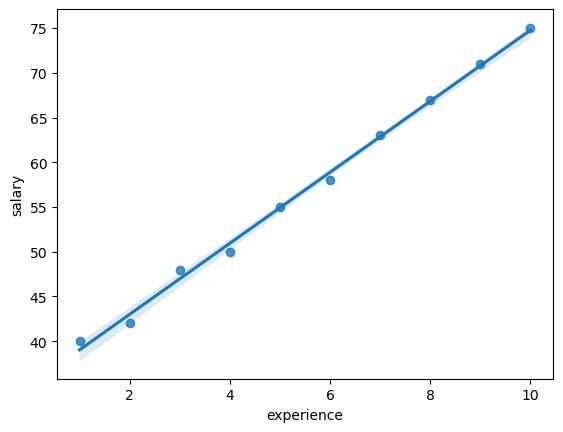

In [18]:
sns.regplot(
    data=df,
    x="experience",
    y="salary"
)

plt.show()

- Если точки располагаются вдоль прямой линии, предпосылка обычно считается выполненной.
- Если наблюдается выраженная кривизна, линейная модель может быть неадекватна.

### Отсутствие мультиколлинеарности

Перед построением регрессии полезно проверить, не дублируют ли факторы друг друга. Если два признака почти полностью описывают одну и ту же информацию, коэффициенты регрессии становятся нестабильными и их сложнее интерпретировать.

**Парные корреляции**

In [20]:
corr = df.corr()

corr

,experience,salary
experience,1.00000,0.99815
salary,0.99815,1.00000


Если корреляции между факторами близки к ±1,
это может говорить о проблемах мультиколлинеарности.

**VIF**

Для более формальной проверки используют коэффициент инфляции дисперсии (VIF).

In [23]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

X_vif = sm.add_constant(
    df
)

vif = pd.DataFrame()

vif["Признак"] = X_vif.columns

vif["VIF"] = [
    variance_inflation_factor(
        X_vif.values,
        i
    )
    for i in range(X_vif.shape[1])
]

vif

,Признак,VIF
0,const,2553.608040
1,experience,270.488065
2,salary,270.488065


Сгенерированный пример – не лучшие данные для расчёта Vif (получаются неадекватные значения), но при работе с реальными данными он будет нам полезен

| VIF  | Интерпретация                   |
| ---- | ------------------------------- |
| < 5  | проблем обычно нет              |
| 5–10 | стоит обратить внимание         |
| > 10 | выраженная мультиколлинеарность |


### Гомоскедастичность

Линейная регрессия предполагает, что разброс остатков остаётся примерно одинаковым во всём диапазоне предсказанных значений.

**Визуальная проверка**

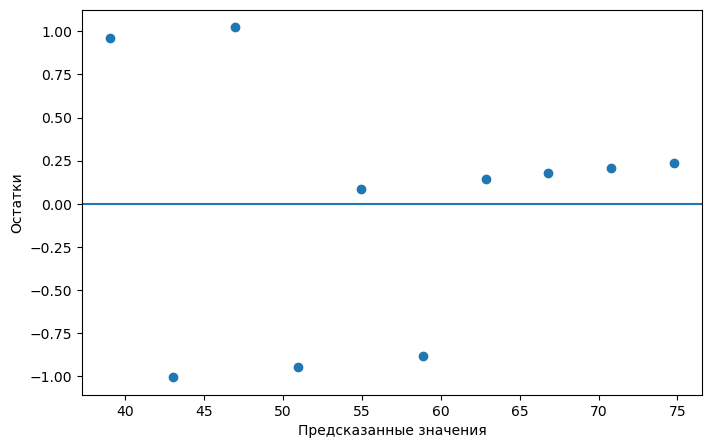

In [24]:
plt.figure(figsize=(8,5))

plt.scatter(
    model.fittedvalues,
    model.resid
)

plt.axhline(0)

plt.xlabel("Предсказанные значения")
plt.ylabel("Остатки")

plt.show()

Смотрим внимательнее на остатки

- Если облако остатков имеет примерно одинаковую ширину, предпосылка выглядит выполненной.
- Если остатки образуют "воронку", возможно нарушение гомоскедастичности.

**Тест Бройша-Пагана**

In [25]:
from statsmodels.stats.diagnostic import het_breuschpagan

bp_stat, bp_pvalue, _, _ = het_breuschpagan(
    model.resid,
    model.model.exog
)

print(bp_pvalue)
   

0.009181552837435158


- p-value > 0.05 — оснований считать предпосылку нарушенной нет
- p-value ≤ 0.05 — есть признаки гетероскедастичности

### Нормальность распределения остатков

Для корректности статистических выводов нужно, чтобы остатки были распределены близко к нормальному распределению.

**Гистограмма**

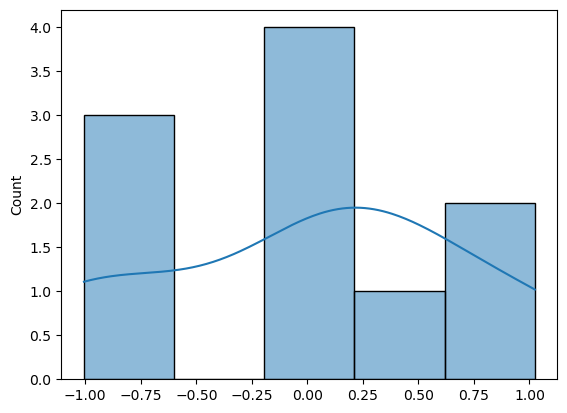

In [26]:
sns.histplot(
    model.resid,
    kde=True
)

plt.show()

**QQ-график**

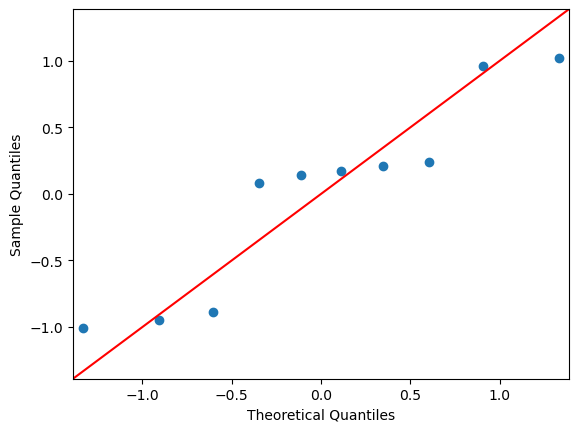

In [27]:
sm.qqplot(
    model.resid,
    line="45"
)

plt.show()

Если точки располагаются близко к диагонали, распределение остатков близко к нормальному.

**Тест Шапиро-Уилка**

In [28]:
stats.shapiro(
    residuals
)

ShapiroResult(statistic=np.float64(0.8705074503204502), pvalue=np.float64(0.10133607173463749))

In [29]:
shapiro_stat, shapiro_p = stats.shapiro(
    model.resid
)

print(shapiro_p)

0.10133607173463749


Смотрим на p-value. Если оно меньше alpha, остатки нельзя считать распределёнными нормально.

# Практическое замечание

В прикладных исследованиях редко встречаются модели, идеально удовлетворяющие всем предпосылкам.

Поэтому предпосылки оценивают комплексно:

- визуально
- с помощью статистических тестов
- с учётом размера выборки

Небольшие отклонения обычно не делают модель бесполезной, но должны быть отражены в интерпретации результатов.

# Множественная регрессия

В реальных задачах результат редко зависит только от одной переменной. Часто используется несколько факторов одновременно.

In [30]:
df = pd.DataFrame({
    "salary": [40,45,50,55,60],
    "experience": [1,2,3,4,5],
    "education": [12,14,16,16,18]
})

В коде ниже мы включаем в модель уже две объясняющие переменные: "experience" и "education".

In [31]:
X = sm.add_constant(
    df[["experience", "education"]]
)

y = df["salary"]

model = sm.OLS(
    y,
    X
).fit()

model.summary()

/lib/python3.13/site-packages/statsmodels/stats/stattools.py:74: ValueWarning: omni_normtest is not valid with less than 8 observations; 5 samples were given.
  warn("omni_normtest is not valid with less than 8 observations; %i "


<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                 salary   R-squared:                       1.000
Model:                            OLS   Adj. R-squared:                  1.000
Method:                 Least Squares   F-statistic:                 1.152e+29
Date:                Wed, 17 Jun 2026   Prob (F-statistic):           8.68e-30
Time:                        01:14:43   Log-Likelihood:                 150.42
No. Observations:                   5   AIC:                            -294.8
Df Residuals:                       2   BIC:                            -296.0
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         35.0000   3.33e-13   1.05e+14      0.000      35.000      35.000
experience     5.0000   4.34e-14   1.15e+14      0.000       5.000       5.000
education   2.165e-15   3.01e-14      0.072      0.949   -1.27e-13    1.32e-13
==============================================================================
Omnibus:                          nan   Durbin-Watson:                   0.279
Prob(Omnibus):                    nan   Jarque-Bera (JB):                0.585
Skew:                           0.244   Prob(JB):                        0.746
Kurtosis:                       1.397   Cond. No.                         358.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

## Прогнозирование

In [32]:
new_employee = pd.DataFrame({
    "const": [1],
    "experience": [8],
    "education": [20]
})

model.predict(new_employee)

0    75.0
dtype: float64

# Вместо вывода

1. Регрессия описывает связь между переменными с помощью уравнения.
2. R² характеризует качество модели.
3. Коэффициенты показывают направление и силу влияния факторов.
4. Значимость коэффициентов оценивается через p-value.
5. Остатки помогают проверить предпосылки модели.
6. Регрессия позволяет прогнозировать значения.
7. Регрессия не доказывает причинно-следственную связь.